Task 1: The Tiny Fingerprint - Linear Scale

Original size: 80 x 80 pixels - way too small!
Goal: scale up 300% on both axes and center it on screen.

2x2 Scaling Matrix:
[[3. 0.]
 [0. 3.]]

Each x-coordinate will be multiplied by 3.0
Each y-coordinate will be multiplied by 3.0

Scaled image size: 240 x 240
Screen size:        800 x 600
Centering offset:   tx = 280.0, ty = 180.0

2x3 Affine Matrix (scale + centering translation):
[[  3.   0. 280.]
 [  0.   3. 180.]]


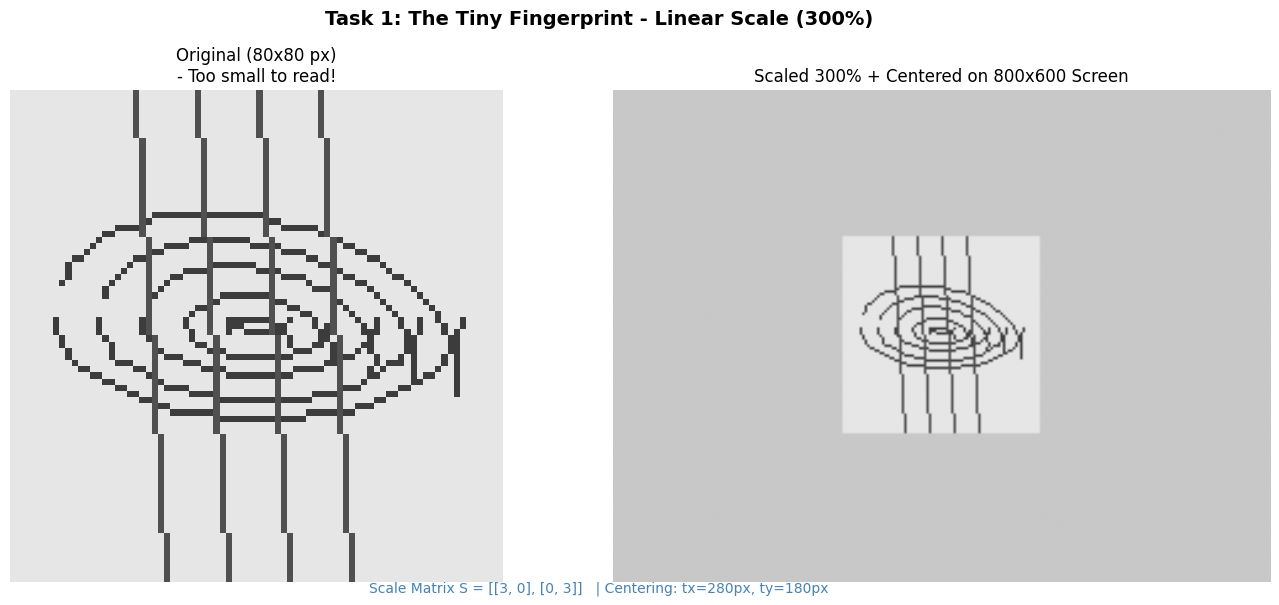


[Done] Output saved to output/task1_scale.png


In [2]:
# task 1

import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)


def make_fingerprint_image(size=80):
    """
    Creates a small synthetic fingerprint-like image using concentric arcs.
    In a real scenario you'd load an actual fingerprint image here.
    """
    img = np.ones((size, size), dtype=np.uint8) * 230  # off-white background

    cx, cy = size // 2, size // 2

    # Draw concentric elliptical arcs to simulate fingerprint ridges
    for r in range(5, size // 2 - 2, 7):
        cv2.ellipse(img, (cx, cy), (r, int(r * 0.6)), 15, 180, 360, 60, 1)
        cv2.ellipse(img, (cx, cy - 3), (r, int(r * 0.5)), 0, 0, 180, 60, 1)

    # Add a few crossing lines to make it look more like a real print
    for offset in range(-size // 4, size // 4, 10):
        cv2.line(img, (cx + offset, 0), (cx + offset + 5, size), 80, 1)

    return img


# --- Load (or create) the fingerprint image ---
fingerprint = make_fingerprint_image(size=80)
h, w = fingerprint.shape[:2]

print("=" * 50)
print("Task 1: The Tiny Fingerprint - Linear Scale")
print("=" * 50)
print(f"\nOriginal size: {w} x {h} pixels - way too small!")
print("Goal: scale up 300% on both axes and center it on screen.\n")


# --- Step 1: Build the 2x2 Scaling Matrix ---
#
# A 2D linear scale transformation is:
#
#   [ x' ]   [ sx   0 ] [ x ]
#   [ y' ] = [  0  sy ] [ y ]
#
# sx = 3.0 means 300% on x-axis (3x original size)
# sy = 3.0 means 300% on y-axis (3x original size)

sx = 3.0   # 300% horizontal scale factor
sy = 3.0   # 300% vertical scale factor

S = np.array([
    [sx,  0.0],
    [0.0,  sy]
], dtype=np.float64)

print("2x2 Scaling Matrix:")
print(S)
print(f"\nEach x-coordinate will be multiplied by {sx}")
print(f"Each y-coordinate will be multiplied by {sy}")


# --- Step 2: Calculate centering offset ---
#
# After scaling, the image dimensions become:
#   new_w = w * sx = 80 * 3 = 240
#   new_h = h * sy = 80 * 3 = 240
#
# To center this on a fixed 800x600 screen:
#   tx = (screen_w - new_w) / 2   <-- shift right to center horizontally
#   ty = (screen_h - new_h) / 2   <-- shift down to center vertically

screen_w, screen_h = 800, 600
new_w = int(w * sx)
new_h = int(h * sy)

tx = (screen_w - new_w) / 2.0
ty = (screen_h - new_h) / 2.0

print(f"\nScaled image size: {new_w} x {new_h}")
print(f"Screen size:        {screen_w} x {screen_h}")
print(f"Centering offset:   tx = {tx:.1f}, ty = {ty:.1f}")


# --- Step 3: Build the 2x3 Affine Matrix ---
#
# cv2.warpAffine() takes a 2x3 matrix that does scale AND translate in one step:
#
#   [ sx    0   tx ]
#   [  0   sy   ty ]
#
# The third column handles the centering translation.

M = np.float32([
    [sx,   0.0,  tx],
    [0.0,  sy,   ty]
])

print("\n2x3 Affine Matrix (scale + centering translation):")
print(M)


# --- Step 4: Apply the transformation ---
result = cv2.warpAffine(
    fingerprint, M,
    (screen_w, screen_h),
    flags=cv2.INTER_LINEAR,    # bilinear interpolation gives smoother edges
    borderValue=200            # fill empty screen space with light gray
)


# --- Visualize results ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Task 1: The Tiny Fingerprint - Linear Scale (300%)',
             fontsize=14, fontweight='bold')

axes[0].imshow(fingerprint, cmap='gray', vmin=0, vmax=255)
axes[0].set_title(f'Original ({w}x{h} px)\n- Too small to read!')
axes[0].axis('off')

axes[1].imshow(result, cmap='gray', vmin=0, vmax=255)
axes[1].set_title(f'Scaled 300% + Centered on {screen_w}x{screen_h} Screen')
axes[1].axis('off')

matrix_text = (f"Scale Matrix S = [[{sx:.0f}, 0], [0, {sy:.0f}]]   "
               f"| Centering: tx={tx:.0f}px, ty={ty:.0f}px")
fig.text(0.5, 0.01, matrix_text, ha='center', fontsize=10, color='steelblue')

plt.tight_layout()
plt.savefig('output/task1_scale.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Done] Output saved to output/task1_scale.png")

Task 2: The Dizzy Satellite - Linear Rotation

The satellite image is rotated 45.0 degrees off true north.
We need to rotate it back by -45 degrees.

2x2 Rotation Matrix R(-45 degrees):
  cos(-45) = 0.7071,  -sin(-45) = 0.7071
  sin(-45) = -0.7071,   cos(-45) = 0.7071

[[ 0.70710678  0.70710678]
 [-0.70710678  0.70710678]]

Original size: 300 x 300

New bounding box calculation:
  new_w = |300 * 0.7071| + |300 * 0.7071| = 424
  new_h = |300 * 0.7071| + |300 * 0.7071| = 424

New canvas size: 424 x 424 (big enough to hold rotated image)

2x3 Rotation + Centering Matrix:
[[ 7.0710677e-01  7.0710677e-01 -1.3203436e-01]
 [-7.0710677e-01  7.0710677e-01  2.1200000e+02]]


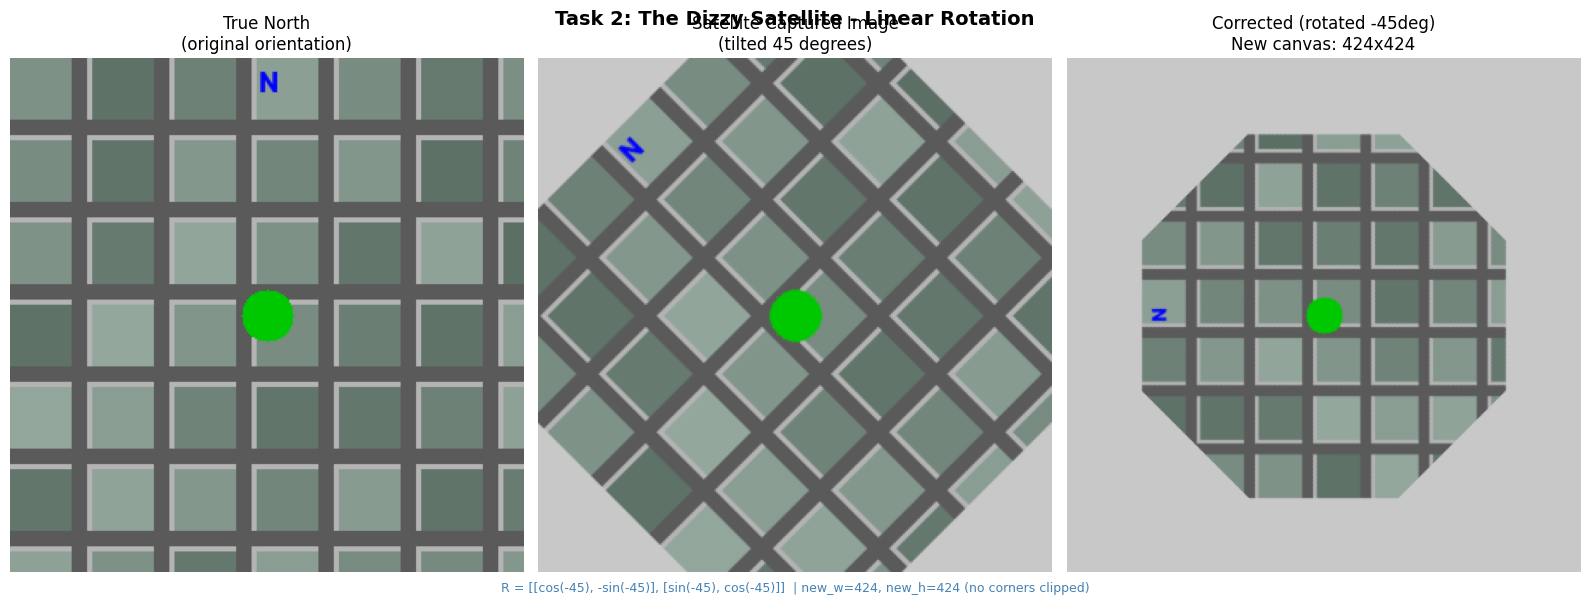


[Done] Output saved to output/task2_rotation.png


In [3]:
#task 2


import cv2
import numpy as np
import matplotlib.pyplot as plt
import os
import math

os.makedirs('output', exist_ok=True)


def make_city_image(size=300):
    """
    Creates a synthetic city grid image (top-down view).
    Simulates a satellite photo of a city with streets and blocks.
    """
    img = np.ones((size, size, 3), dtype=np.uint8) * 180  # gray pavement

    # Draw city blocks (rectangles)
    block_size = 40
    road_w = 8
    for row in range(0, size, block_size + road_w):
        for col in range(0, size, block_size + road_w):
            # Each block is a building (slightly different shade for variety)
            shade = np.random.randint(100, 160)
            cv2.rectangle(img, (col, row),
                          (col + block_size, row + block_size),
                          (shade, shade + 10, shade - 10), -1)

    # Draw road lines (horizontal and vertical streets)
    for i in range(0, size, block_size + road_w):
        cv2.line(img, (0, i + block_size), (size, i + block_size), (90, 90, 90), road_w)
        cv2.line(img, (i + block_size, 0), (i + block_size, size), (90, 90, 90), road_w)

    # Add a landmark at the center
    cx, cy = size // 2, size // 2
    cv2.circle(img, (cx, cy), 15, (0, 200, 0), -1)   # green park
    cv2.putText(img, "N", (cx - 5, 20), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

    return img


# Create a clean city image, then deliberately rotate it 45 degrees to simulate
# what the satellite captured after the collision
city_original = make_city_image(300)
h, w = city_original.shape[:2]

# Simulate the 45-degree tilt the satellite introduced
tilt_angle = 45.0
M_tilt = cv2.getRotationMatrix2D((w / 2, h / 2), tilt_angle, 1.0)
city_tilted = cv2.warpAffine(city_original, M_tilt, (w, h), borderValue=(200, 200, 200))


print("=" * 50)
print("Task 2: The Dizzy Satellite - Linear Rotation")
print("=" * 50)
print(f"\nThe satellite image is rotated {tilt_angle} degrees off true north.")
print("We need to rotate it back by -45 degrees.\n")


# --- Step 1: Formulate the 2x2 Rotation Matrix ---
#
# A 2D rotation matrix for angle theta is:
#
#   R(theta) = [ cos(theta)  -sin(theta) ]
#              [ sin(theta)   cos(theta) ]
#
# To correct a +45 degree tilt, we rotate by -45 degrees.

theta_deg = -45.0                       # correction angle (rotate back)
theta_rad = math.radians(theta_deg)     # convert to radians for trig functions

cos_t = math.cos(theta_rad)
sin_t = math.sin(theta_rad)

R = np.array([
    [cos_t, -sin_t],
    [sin_t,  cos_t]
], dtype=np.float64)

print("2x2 Rotation Matrix R(-45 degrees):")
print(f"  cos(-45) = {cos_t:.4f},  -sin(-45) = {-sin_t:.4f}")
print(f"  sin(-45) = {sin_t:.4f},   cos(-45) = {cos_t:.4f}")
print()
print(R)


# --- Step 2: Manually calculate new bounding box dimensions ---
#
# When we rotate a rectangle, the corners move outside the original bounds.
# The new bounding box needed to contain the rotated image (without clipping) is:
#
#   new_w = |w * cos(theta)| + |h * sin(theta)|
#   new_h = |w * sin(theta)| + |h * cos(theta)|
#
# This is the "safe" canvas size that won't chop any corners off.

abs_cos = abs(cos_t)
abs_sin = abs(sin_t)

new_w = int(w * abs_cos + h * abs_sin)
new_h = int(w * abs_sin + h * abs_cos)

print(f"\nOriginal size: {w} x {h}")
print(f"\nNew bounding box calculation:")
print(f"  new_w = |{w} * {abs_cos:.4f}| + |{h} * {abs_sin:.4f}| = {new_w}")
print(f"  new_h = |{w} * {abs_sin:.4f}| + |{h} * {abs_cos:.4f}| = {new_h}")
print(f"\nNew canvas size: {new_w} x {new_h} (big enough to hold rotated image)")


# --- Step 3: Build the rotation matrix centered on the image ---
#
# We want to rotate around the image center, not the origin (0,0).
# cv2.getRotationMatrix2D handles this nicely - it builds the full 2x3 matrix.
# Internally it does: translate to origin -> rotate -> translate back -> center on new canvas

# Center of the ORIGINAL tilted image
cx_old = w / 2.0
cy_old = h / 2.0

# Center of the NEW (larger) canvas
cx_new = new_w / 2.0
cy_new = new_h / 2.0

# Build the 2x3 matrix manually using our rotation matrix R
# Translation keeps the rotated image centered on the new canvas
M_correct = np.float32([
    [cos_t, -sin_t, cx_new - cos_t * cx_old + sin_t * cy_old],
    [sin_t,  cos_t, cy_new - sin_t * cx_old - cos_t * cy_old]
])

print("\n2x3 Rotation + Centering Matrix:")
print(M_correct)


# --- Step 4: Apply the correction ---
corrected = cv2.warpAffine(
    city_tilted, M_correct,
    (new_w, new_h),
    flags=cv2.INTER_LINEAR,
    borderValue=(200, 200, 200)
)


# --- Visualize ---
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Task 2: The Dizzy Satellite - Linear Rotation',
             fontsize=14, fontweight='bold')

axes[0].imshow(cv2.cvtColor(city_original, cv2.COLOR_BGR2RGB))
axes[0].set_title('True North\n(original orientation)')
axes[0].axis('off')

axes[1].imshow(cv2.cvtColor(city_tilted, cv2.COLOR_BGR2RGB))
axes[1].set_title('Satellite Captured Image\n(tilted 45 degrees)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(corrected, cv2.COLOR_BGR2RGB))
axes[2].set_title(f'Corrected (rotated -45deg)\nNew canvas: {new_w}x{new_h}')
axes[2].axis('off')

fig.text(0.5, 0.01,
         f"R = [[cos(-45), -sin(-45)], [sin(-45), cos(-45)]]  "
         f"| new_w={new_w}, new_h={new_h} (no corners clipped)",
         ha='center', fontsize=9, color='steelblue')

plt.tight_layout()
plt.savefig('output/task2_rotation.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n[Done] Output saved to output/task2_rotation.png")